# 🤖 Machine Learning - Academic Failure Risk Prediction

This notebook documents the Machine Learning stage of the project.

The objective is to build a classification model that predicts whether a student is at risk of academic failure.

### Target Variable

```text
Academic_Failure_Risk
```

Target meaning:

- `0` → No Academic Failure Risk
- `1` → Academic Failure Risk

The Machine Learning workflow includes:

1. Load cleaned data
2. Prepare features and target
3. Feature engineering
4. Identify numerical and categorical features
5. Build preprocessing pipeline
6. Split data into training and testing sets
7. Train Random Forest model
8. Evaluate model performance
9. Analyze confusion matrix
10. Save the trained model and preprocessor
11. Save all results and visualizations


## 📦 1. Import Required Libraries

We use the project modules instead of duplicating the Machine Learning implementation inside the notebook.

In [89]:
import os
import sys

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
    
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

# Add the project root directory to Python path.
PROJECT_ROOT = os.path.abspath("..")

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

print("✅ Libraries imported successfully.")
print(f"📁 Project root: {PROJECT_ROOT}")

✅ Libraries imported successfully.
📁 Project root: c:\Users\ayman\OneDrive\Desktop\data-analysis-project


## 📂 2. Project Paths

The cleaned dataset is stored in `data/processed/` and trained models are stored in `models/`.

In [90]:
CLEANED_DATA_PATH = os.path.join(
    PROJECT_ROOT,
    "data",
    "processed",
    "AI_SocialMedia_Student_Health_Dataset_clean.csv"
)

MODEL_PATH = os.path.join(
    PROJECT_ROOT,
    "models",
    "random_forest_model.pkl"
)

PREPROCESSOR_PATH = os.path.join(
    PROJECT_ROOT,
    "models",
    "preprocessor.pkl"
)

print("📂 Project Paths:")
print("-" * 50)
print(f"Cleaned dataset: {CLEANED_DATA_PATH}")
print(f"Model path:      {MODEL_PATH}")
print(f"Preprocessor:    {PREPROCESSOR_PATH}")
print("-" * 50)

📂 Project Paths:
--------------------------------------------------
Cleaned dataset: c:\Users\ayman\OneDrive\Desktop\data-analysis-project\data\processed\AI_SocialMedia_Student_Health_Dataset_clean.csv
Model path:      c:\Users\ayman\OneDrive\Desktop\data-analysis-project\models\random_forest_model.pkl
Preprocessor:    c:\Users\ayman\OneDrive\Desktop\data-analysis-project\models\preprocessor.pkl
--------------------------------------------------


## 📥 3. Load Cleaned Dataset

The Machine Learning stage uses the cleaned dataset generated by the data-cleaning pipeline.

The raw dataset is not modified.

In [91]:
if not os.path.exists(CLEANED_DATA_PATH):
    raise FileNotFoundError(
        f"❌ Cleaned dataset not found at: {CLEANED_DATA_PATH}"
    )

df = pd.read_csv(CLEANED_DATA_PATH)

print("✅ Dataset loaded successfully.")
print(f"📊 Rows: {df.shape[0]:,}")
print(f"📊 Columns: {df.shape[1]}")


✅ Dataset loaded successfully.
📊 Rows: 15,000
📊 Columns: 14


## 👀 4. Inspect the Dataset

In [92]:
display(df.head())

print("\n📋 Column names:")
print(df.columns.tolist())

print("\n📋 Data types:")
display(df.dtypes)


,Student_ID,Age,Gender,Education_Level,Daily_Social_Media_Hours,Daily_AI_Tool_Usage_Hours,Sleep_Hours,Physical_Activity_Hours,Mental_Health_Score,Physical_Health_Score,Social_Isolation_Score,Burnout_Level,Academic_Performance_Score,Academic_Failure_Risk
0,STU_00001,19,Male,College,5.32,1.21,7.30,1.41,74.06,98.90,4.05,Low,88.80,0
1,STU_00002,16,Non-binary,High School,5.21,3.89,7.81,2.48,76.13,89.94,4.65,Moderate,50.60,0
2,STU_00003,25,Male,University,3.61,2.65,6.34,0.06,65.01,76.75,5.28,Low,96.67,0
3,STU_00004,23,Male,University,2.93,1.43,6.12,1.37,74.67,87.38,3.66,Low,85.65,0
4,STU_00005,20,Non-binary,College,6.52,1.64,5.23,1.14,67.74,88.04,3.25,Moderate,71.84,0



📋 Column names:
['Student_ID', 'Age', 'Gender', 'Education_Level', 'Daily_Social_Media_Hours', 'Daily_AI_Tool_Usage_Hours', 'Sleep_Hours', 'Physical_Activity_Hours', 'Mental_Health_Score', 'Physical_Health_Score', 'Social_Isolation_Score', 'Burnout_Level', 'Academic_Performance_Score', 'Academic_Failure_Risk']

📋 Data types:


Student_ID                        str
Age                             int64
Gender                            str
Education_Level                   str
Daily_Social_Media_Hours      float64
Daily_AI_Tool_Usage_Hours     float64
Sleep_Hours                   float64
Physical_Activity_Hours       float64
Mental_Health_Score           float64
Physical_Health_Score         float64
Social_Isolation_Score        float64
Burnout_Level                     str
Academic_Performance_Score    float64
Academic_Failure_Risk           int64
dtype: object

## 🎯 5. Define Target Variable

The target variable is `Academic_Failure_Risk`.

This is a binary classification problem.

In [93]:
TARGET_COLUMN = "Academic_Failure_Risk"

if TARGET_COLUMN not in df.columns:
    raise ValueError(
        f"❌ Target column '{TARGET_COLUMN}' was not found in the dataset."
    )

X = df.drop(columns=[TARGET_COLUMN])
y = df[TARGET_COLUMN]

print(f"✅ Features shape: {X.shape}")
print(f"✅ Target shape: {y.shape}")


✅ Features shape: (15000, 13)
✅ Target shape: (15000,)


## 📊 6. Target Distribution

Before training a classification model, it is important to understand how the target classes are distributed.

In [94]:
target_counts = y.value_counts().sort_index()
target_percentages = (
    y.value_counts(normalize=True).sort_index() * 100
).round(2)

print("📊 Target counts:")
display(target_counts)

print("📊 Target percentages:")
display(target_percentages)


📊 Target counts:


Academic_Failure_Risk
0    14100
1      900
Name: count, dtype: int64

📊 Target percentages:


Academic_Failure_Risk
0    94.0
1     6.0
Name: proportion, dtype: float64

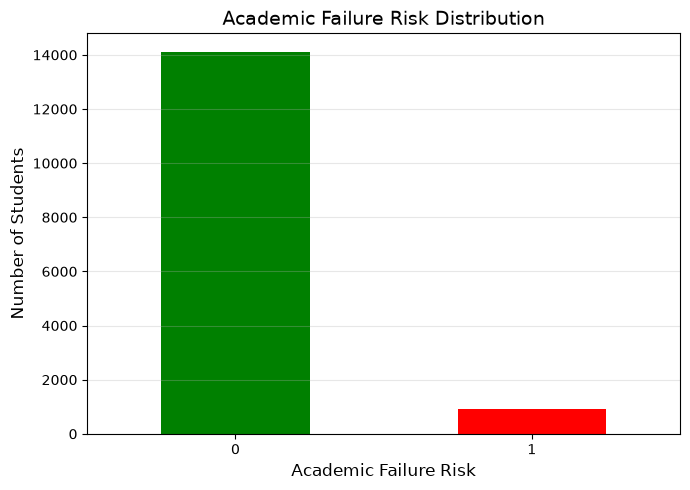

In [95]:
plt.figure(figsize=(7, 5))

target_counts.plot(kind="bar", color=['green', 'red'])

plt.title("Academic Failure Risk Distribution", fontsize=14)
plt.xlabel("Academic Failure Risk", fontsize=12)
plt.ylabel("Number of Students", fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


### Target Distribution Observation

The dataset contains significantly more students in class `0` than class `1`.

Therefore, accuracy alone should not be used to judge the model. Precision, recall, F1-score, confusion matrix, and ROC-AUC are also important.

## 🛠️ 7. Feature Engineering & Preprocessing

The project creates additional features from existing variables:

- `Uses_AI_Tools`
- `Is_Social_Media_User`
- `Is_Physically_Active`

These features provide simple indicators that may help the model capture useful patterns.

**Note:** We remove `Student_ID` column as it's not useful for prediction.

In [96]:
# ============================================================
# FEATURE ENGINEERING & PREPROCESSING
# ============================================================

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

print("\n" + "="*70)
print("FEATURE ENGINEERING & PREPROCESSING")
print("="*70)

# 1. Create engineered features
df['Uses_AI_Tools'] = (df['Daily_AI_Tool_Usage_Hours'] > 0).astype(int)
df['Is_Social_Media_User'] = (df['Daily_Social_Media_Hours'] > 0).astype(int)
df['Is_Physically_Active'] = (df['Physical_Activity_Hours'] > 0).astype(int)

print("✅ Engineered features created:")
print("  - Uses_AI_Tools")
print("  - Is_Social_Media_User")
print("  - Is_Physically_Active")

# 2. Separate features and target (remove Student_ID)
TARGET_COLUMN = "Academic_Failure_Risk"
columns_to_drop = [TARGET_COLUMN, "Student_ID"]
X = df.drop(columns=columns_to_drop)
y = df[TARGET_COLUMN]

print(f"\n✅ Features shape: {X.shape}")
print(f"✅ Target shape: {y.shape}")

# 3. Identify column types
numerical_columns = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_columns = X.select_dtypes(include=['object']).columns.tolist()

print("\n🔢 Numerical columns:")
for col in numerical_columns:
    print(f"  - {col}")

print("\n🔤 Categorical columns:")
for col in categorical_columns:
    print(f"  - {col}")

# 4. Build preprocessing pipeline
numerical_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_columns),
        ('cat', categorical_transformer, categorical_columns)
    ]
)

# 5. Apply preprocessing
X_processed = preprocessor.fit_transform(X)

print(f"\n✅ Preprocessing completed.")
print(f"📊 Processed features shape: {X_processed.shape}")
print(f"📊 Target shape: {y.shape}")
print("="*70)



FEATURE ENGINEERING & PREPROCESSING
✅ Engineered features created:
  - Uses_AI_Tools
  - Is_Social_Media_User
  - Is_Physically_Active

✅ Features shape: (15000, 15)
✅ Target shape: (15000,)

🔢 Numerical columns:
  - Age
  - Daily_Social_Media_Hours
  - Daily_AI_Tool_Usage_Hours
  - Sleep_Hours
  - Physical_Activity_Hours
  - Mental_Health_Score
  - Physical_Health_Score
  - Social_Isolation_Score
  - Academic_Performance_Score
  - Uses_AI_Tools
  - Is_Social_Media_User
  - Is_Physically_Active

🔤 Categorical columns:
  - Gender
  - Education_Level
  - Burnout_Level

✅ Preprocessing completed.
📊 Processed features shape: (15000, 22)
📊 Target shape: (15000,)


C:\Users\ayman\AppData\Local\Temp\ipykernel_23132\3810484417.py:34: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X.select_dtypes(include=['object']).columns.tolist()


## ✂️ 8. Train/Test Split

The dataset is divided into:

- 80% training data
- 20% testing data

The test set is kept separate so that the final model can be evaluated on unseen data.

In [97]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_processed,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("📊 Training data:")
print(f"  X_train: {X_train.shape}")
print(f"  y_train: {y_train.shape}")

print("\n📊 Testing data:")
print(f"  X_test: {X_test.shape}")
print(f"  y_test: {y_test.shape}")


📊 Training data:
  X_train: (12000, 22)
  y_train: (12000,)

📊 Testing data:
  X_test: (3000, 22)
  y_test: (3000,)


## 🌲 9. Train Random Forest Model

The project uses a Random Forest classifier as the main Machine Learning model.

Random Forest is suitable for this classification problem because it can model non-linear relationships and interactions between features.

In [98]:
from sklearn.ensemble import RandomForestClassifier

# ============================================================
# CREATE MACHINE LEARNING MODEL
# ============================================================

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

print("🌲 Random Forest model created successfully.")
print(f"  - n_estimators: {model.n_estimators}")
print(f"  - random_state: {model.random_state}")
print(f"  - class_weight: {model.class_weight}")

# ============================================================
# TRAIN MODEL
# ============================================================

print("\n" + "="*70)
print("TRAINING MODEL")
print("="*70)

trained_model = model.fit(X_train, y_train)

print("✅ Model training completed successfully.")
print("="*70)


🌲 Random Forest model created successfully.
  - n_estimators: 100
  - random_state: 42
  - class_weight: balanced

TRAINING MODEL
✅ Model training completed successfully.


## 📈 10. Evaluate the Trained Model

The evaluation stage measures how well the model performs on unseen testing data.

The project evaluates:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix
- ROC-AUC

In [99]:
# ============================================================
# EVALUATE MODEL ON TEST DATA
# ============================================================

# Make predictions
y_pred = trained_model.predict(X_test)
y_pred_proba = trained_model.predict_proba(X_test)[:, 1]

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("=" * 60)
print("📊 MODEL EVALUATION RESULTS")
print("=" * 60)
print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["No Risk", "At Risk"]))
print("=" * 60)


📊 MODEL EVALUATION RESULTS
Accuracy:  0.9940 (99.40%)
Precision: 0.9219
Recall:    0.9833
F1-Score:  0.9516
ROC-AUC:   0.9996

Classification Report:
              precision    recall  f1-score   support

     No Risk       1.00      0.99      1.00      2820
     At Risk       0.92      0.98      0.95       180

    accuracy                           0.99      3000
   macro avg       0.96      0.99      0.97      3000
weighted avg       0.99      0.99      0.99      3000



## 🧩 11. Confusion Matrix

The confusion matrix provides a more detailed view of classification errors.

For academic failure prediction, false negatives are particularly important because they represent students who are actually at risk but were predicted as not being at risk.

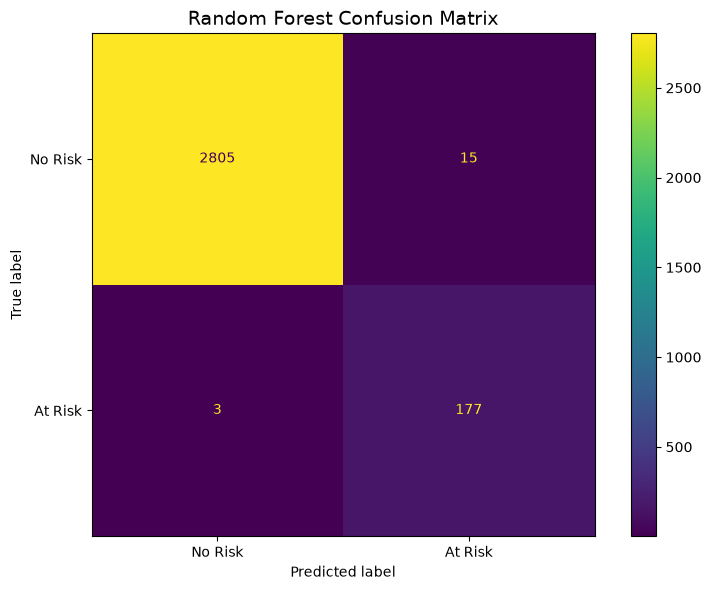

📊 Confusion Matrix:
[[2805   15]
 [   3  177]]

✅ True Negatives:  2,805
❌ False Positives: 15
❌ False Negatives: 3
✅ True Positives:  177


In [100]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Risk", "At Risk"]
)

disp.plot(ax=ax)
plt.title("Random Forest Confusion Matrix", fontsize=14)
plt.tight_layout()
plt.show()

print("📊 Confusion Matrix:")
print(cm)
print(f"\n✅ True Negatives:  {cm[0,0]:,}")
print(f"❌ False Positives: {cm[0,1]:,}")
print(f"❌ False Negatives: {cm[1,0]:,}")
print(f"✅ True Positives:  {cm[1,1]:,}")


## 📊 12. ROC Curve

The ROC curve shows the trade-off between true positive rate and false positive rate across different classification thresholds.

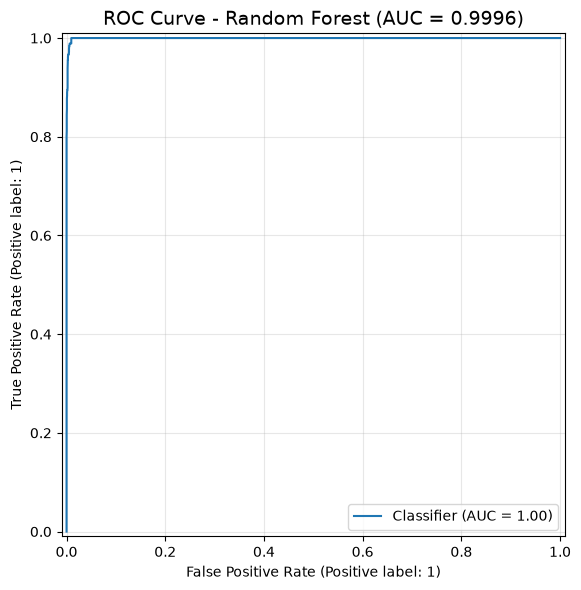

In [101]:
fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_predictions(y_test, y_pred_proba, ax=ax)
plt.title(f"ROC Curve - Random Forest (AUC = {roc_auc:.4f})", fontsize=14)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 🔍 13. Feature Importance Analysis

Understanding which features are most important helps interpret the model and identify key factors influencing academic failure risk.

FEATURE IMPORTANCE ANALYSIS
Number of importances: 22
Number of feature names: 22
Number of importances:   22

📊 Top 10 Most Important Features:
----------------------------------------------------------------------
                   Feature  Importance
         Burnout_Level_Low    0.175369
      Burnout_Level_Severe    0.167056
        Burnout_Level_High    0.131213
Academic_Performance_Score    0.122564
       Mental_Health_Score    0.111884
    Burnout_Level_Moderate    0.111581
  Daily_Social_Media_Hours    0.089616
               Sleep_Hours    0.024742
    Social_Isolation_Score    0.017053
 Daily_AI_Tool_Usage_Hours    0.014868
----------------------------------------------------------------------
FEATURE IMPORTANCE SAVED
CSV: C:\Users\ayman\OneDrive\Desktop\data-analysis-project\reports\tables\random_forest_feature_importance.csv
PNG: C:\Users\ayman\OneDrive\Desktop\data-analysis-project\reports\figures\random_forest_feature_importance.png


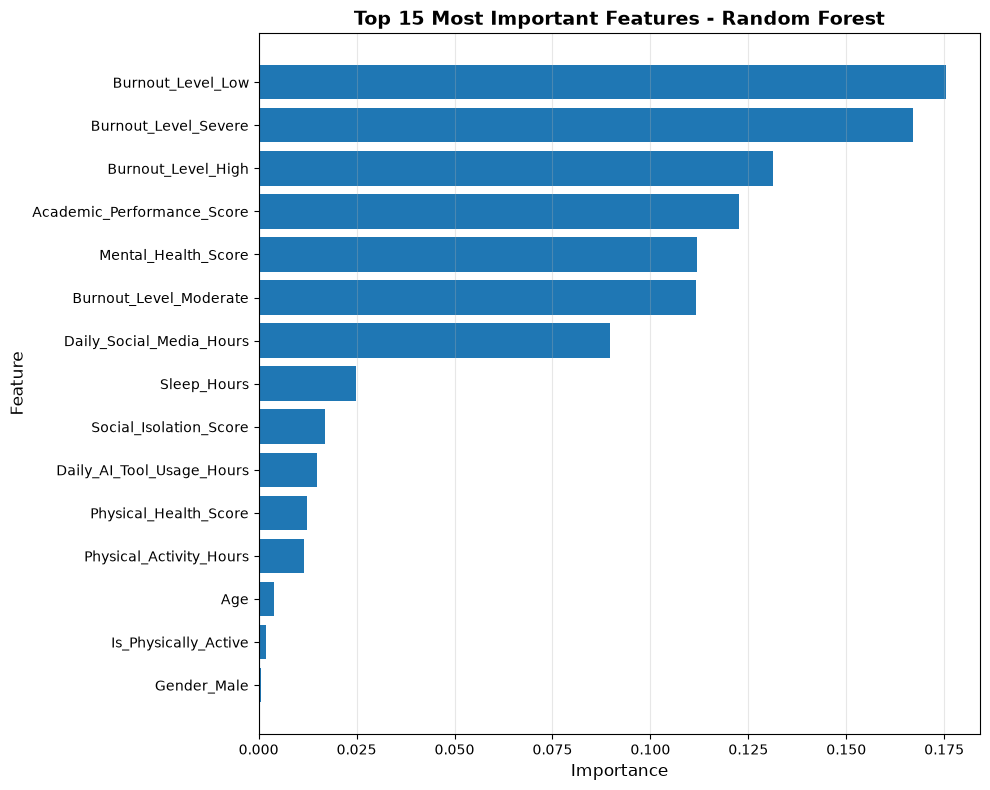


✅ FEATURE IMPORTANCE COMPLETED
🖼️ PNG: C:\Users\ayman\OneDrive\Desktop\data-analysis-project\reports\figures\random_forest_feature_importance.png
📊 CSV: C:\Users\ayman\OneDrive\Desktop\data-analysis-project\reports\tables\random_forest_feature_importance.csv


In [102]:
# ============================================================
# FEATURE IMPORTANCE WITH CORRECT FEATURE NAMES
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

from utils.report_utils import save_feature_importance


# ============================================================
# GET FEATURE IMPORTANCES FROM RANDOM FOREST
# ============================================================

# Random Forest stores the importance of every processed feature
importances = model.feature_importances_


print("=" * 70)
print("FEATURE IMPORTANCE ANALYSIS")
print("=" * 70)

print(f"Number of importances: {len(importances)}")


# ============================================================
# GET FEATURE NAMES FROM PREPROCESSOR
# ============================================================

# Get the names of the features after preprocessing.
#
# This is better than manually creating category names because
# OneHotEncoder may create feature names automatically.

try:

    all_feature_names = preprocessor.get_feature_names_out()

    # Remove transformer prefixes such as:
    # num__Age
    # cat__Gender_Male
    #
    # This makes the final report easier to read.

    all_feature_names = [
        name.split("__", 1)[-1]
        for name in all_feature_names
    ]

except Exception as error:

    print("\n⚠️ Could not get feature names from preprocessor.")
    print(f"Reason: {error}")

    # Fallback names
    all_feature_names = [
        f"Feature_{i}"
        for i in range(len(importances))
    ]


# ============================================================
# CHECK FEATURE COUNTS
# ============================================================

print(f"Number of feature names: {len(all_feature_names)}")
print(f"Number of importances:   {len(importances)}")


# ============================================================
# CREATE FEATURE IMPORTANCE DATAFRAME
# ============================================================

if len(all_feature_names) != len(importances):

    raise ValueError(
        "Feature name count does not match "
        "feature importance count."
    )


importance_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": importances
})


# Sort from most important to least important
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)


# ============================================================
# DISPLAY TOP 10 FEATURES
# ============================================================

print("\n📊 Top 10 Most Important Features:")
print("-" * 70)

print(
    importance_df
    .head(10)
    .to_string(index=False)
)

print("-" * 70)


# ============================================================
# CREATE TOP 15 FEATURE IMPORTANCE FIGURE
# ============================================================

top_features = importance_df.head(15).sort_values(
    by="Importance",
    ascending=True
)


fig, ax = plt.subplots(
    figsize=(10, 8)
)


ax.barh(
    top_features["Feature"],
    top_features["Importance"]
)


ax.set_xlabel(
    "Importance",
    fontsize=12
)


ax.set_ylabel(
    "Feature",
    fontsize=12
)


ax.set_title(
    "Top 15 Most Important Features - Random Forest",
    fontsize=14,
    fontweight="bold"
)


ax.grid(
    axis="x",
    alpha=0.3
)


fig.tight_layout()


# ============================================================
# SAVE FEATURE IMPORTANCE
# ============================================================

feature_report = save_feature_importance(
    feature_names=importance_df["Feature"],
    importance_values=importance_df["Importance"],
    filename="random_forest_feature_importance"
)


# ============================================================
# DISPLAY FIGURE
# ============================================================

plt.show()


# ============================================================
# FINAL OUTPUT
# ============================================================

print("\n" + "=" * 70)
print("✅ FEATURE IMPORTANCE COMPLETED")
print("=" * 70)

print(f"🖼️ PNG: {feature_report['png']}")
print(f"📊 CSV: {feature_report['csv']}")

print("=" * 70)

## 🎯 14. Class-wise Performance Metrics

In [103]:
# ============================================================
# SAVE FEATURE IMPORTANCE
# ============================================================

from utils.report_utils import save_dataframe


# Save feature importance as CSV
csv_path = save_dataframe(
    dataframe=importance_df,
    filename="feature_importance"
)


print("\n✅ Feature importance saved to CSV!")
print(f"📊 Location: {csv_path}")

Table saved: C:\Users\ayman\OneDrive\Desktop\data-analysis-project\reports\tables\feature_importance.csv

✅ Feature importance saved to CSV!
📊 Location: C:\Users\ayman\OneDrive\Desktop\data-analysis-project\reports\tables\feature_importance.csv


## 💾 15. Save Model and Preprocessor

In [104]:
import joblib

# Create models directory if it doesn't exist
os.makedirs(os.path.dirname(MODEL_PATH), exist_ok=True)

# Save the trained model
joblib.dump(trained_model, MODEL_PATH)

# Save the preprocessor
joblib.dump(preprocessor, PREPROCESSOR_PATH)

print("✅ Model saved to:", MODEL_PATH)
print("✅ Preprocessor saved to:", PREPROCESSOR_PATH)

# Verify files were saved
print("\n📁 Verification:")
print(f"  Model exists: {os.path.exists(MODEL_PATH)}")
print(f"  Preprocessor exists: {os.path.exists(PREPROCESSOR_PATH)}")

# Show file sizes
if os.path.exists(MODEL_PATH):
    model_size = os.path.getsize(MODEL_PATH) / (1024 * 1024)  # MB
    print(f"\n📊 File sizes:")
    print(f"  Model: {model_size:.2f} MB")
if os.path.exists(PREPROCESSOR_PATH):
    preprocessor_size = os.path.getsize(PREPROCESSOR_PATH) / (1024 * 1024)  # MB
    print(f"  Preprocessor: {preprocessor_size:.2f} MB")


✅ Model saved to: c:\Users\ayman\OneDrive\Desktop\data-analysis-project\models\random_forest_model.pkl
✅ Preprocessor saved to: c:\Users\ayman\OneDrive\Desktop\data-analysis-project\models\preprocessor.pkl

📁 Verification:
  Model exists: True
  Preprocessor exists: True

📊 File sizes:
  Model: 2.29 MB
  Preprocessor: 0.00 MB


## 📁 16. Save All Results

Now we save all model results, metrics, and visualizations to the reports directory.

In [105]:
# ============================================================
# REPORT UTILITIES - EMBEDDED VERSION (NO IMPORT NEEDED)
# ============================================================

from pathlib import Path
import json
import os
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# PROJECT PATHS
# ============================================================

PROJECT_ROOT = Path(os.path.abspath(".."))

# مجلد التقارير الرئيسي
REPORTS_DIR = PROJECT_ROOT / "reports"

# المجلدات الفرعية
FIGURES_DIR = REPORTS_DIR / "figures"
TABLES_DIR = REPORTS_DIR / "tables"
SUMMARIES_DIR = REPORTS_DIR / "summaries"

# إنشاء المجلدات
for dir_path in [REPORTS_DIR, FIGURES_DIR, TABLES_DIR, SUMMARIES_DIR]:
    dir_path.mkdir(parents=True, exist_ok=True)

print(f"✅ Created directories in: {REPORTS_DIR}")

# ============================================================
# FUNCTIONS
# ============================================================

def get_results_directory():
    """الحصول على مسار مجلد النتائج"""
    return REPORTS_DIR

def get_reports_dir():
    return REPORTS_DIR

def get_figures_dir():
    return FIGURES_DIR

def get_tables_dir():
    return TABLES_DIR

def get_summaries_dir():
    return SUMMARIES_DIR

def save_json(data, filename, subfolder="summaries", print_path=True):
    """حفظ البيانات في ملف JSON."""
    if subfolder == "figures":
        output_path = FIGURES_DIR / filename
    elif subfolder == "tables":
        output_path = TABLES_DIR / filename
    else:
        output_path = SUMMARIES_DIR / filename
    
    output_path.parent.mkdir(parents=True, exist_ok=True)
    
    with open(output_path, "w", encoding="utf-8") as file:
        json.dump(data, file, indent=4, ensure_ascii=False)
    
    if print_path:
        print(f"✅ Saved JSON: {output_path}")
    return str(output_path)

def save_csv(dataframe, filename, subfolder="tables", print_path=True):
    """حفظ DataFrame في ملف CSV."""
    if subfolder == "figures":
        output_path = FIGURES_DIR / filename
    elif subfolder == "summaries":
        output_path = SUMMARIES_DIR / filename
    else:
        output_path = TABLES_DIR / filename
    
    output_path.parent.mkdir(parents=True, exist_ok=True)
    dataframe.to_csv(output_path, index=False)
    
    if print_path:
        print(f"✅ Saved CSV: {output_path}")
    return str(output_path)

def save_text(text, filename, subfolder="summaries", print_path=True):
    """حفظ النص في ملف TXT."""
    if subfolder == "figures":
        output_path = FIGURES_DIR / filename
    elif subfolder == "tables":
        output_path = TABLES_DIR / filename
    else:
        output_path = SUMMARIES_DIR / filename
    
    output_path.parent.mkdir(parents=True, exist_ok=True)
    
    with open(output_path, "w", encoding="utf-8") as file:
        file.write(text)
    
    if print_path:
        print(f"✅ Saved Text: {output_path}")
    return str(output_path)

def save_figure(filename, dpi=300, bbox_inches="tight", subfolder="figures", print_path=True):
    """حفظ الرسم البياني الحالي في ملف صورة."""
    if subfolder == "tables":
        output_path = TABLES_DIR / filename
    elif subfolder == "summaries":
        output_path = SUMMARIES_DIR / filename
    else:
        output_path = FIGURES_DIR / filename
    
    output_path.parent.mkdir(parents=True, exist_ok=True)
    
    plt.savefig(
        output_path,
        dpi=dpi,
        bbox_inches=bbox_inches,
        facecolor='white',
        edgecolor='none'
    )
    
    if print_path:
        print(f"✅ Saved Figure: {output_path}")
    return str(output_path)

def save_classification_report(y_true, y_pred, target_names=None, filename="classification_report.txt", subfolder="summaries", print_path=True):
    """إنشاء وحفظ تقرير التصنيف كملف نصي."""
    from sklearn.metrics import classification_report
    
    report = classification_report(y_true, y_pred, target_names=target_names)
    
    timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    header = "=" * 70 + "\n"
    header += f"CLASSIFICATION REPORT\n"
    header += f"Generated: {timestamp}\n"
    header += "=" * 70 + "\n\n"
    
    full_report = header + report
    
    return save_text(full_report, filename, subfolder, print_path)

def save_metrics_summary(metrics_dict, filename="metrics_summary.json", subfolder="summaries", print_path=True):
    """حفظ مقاييس النموذج كملف JSON."""
    
    def convert_to_serializable(obj):
        if isinstance(obj, np.integer):
            return int(obj)
        elif isinstance(obj, np.floating):
            return float(obj)
        elif isinstance(obj, np.ndarray):
            return obj.tolist()
        elif isinstance(obj, Path):
            return str(obj)
        elif isinstance(obj, pd.Series):
            return obj.tolist()
        elif isinstance(obj, pd.DataFrame):
            return obj.to_dict('records')
        return obj
    
    metrics_dict['generated_at'] = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    
    serializable_metrics = {}
    for key, value in metrics_dict.items():
        try:
            serializable_metrics[key] = convert_to_serializable(value)
        except:
            serializable_metrics[key] = str(value)
    
    return save_json(serializable_metrics, filename, subfolder, print_path)

def list_saved_files(verbose=True):
    """عرض جميع الملفات المحفوظة في مجلد التقارير."""
    print("\n" + "=" * 70)
    print("📁 FILES SAVED IN REPORTS DIRECTORY")
    print("=" * 70)
    
    total_files = 0
    total_size = 0
    all_files = []
    
    folders = [
        ('📊 Figures', FIGURES_DIR),
        ('📋 Tables', TABLES_DIR),
        ('📝 Summaries', SUMMARIES_DIR)
    ]
    
    for folder_name, folder_path in folders:
        if folder_path.exists():
            files = list(folder_path.iterdir())
            if files:
                print(f"\n{folder_name} ({len(files)} files):")
                print("-" * 50)
                for file in sorted(files):
                    if file.is_file():
                        size = file.stat().st_size / 1024
                        total_size += size
                        total_files += 1
                        all_files.append(file.name)
                        print(f"  📄 {file.name:<40} ({size:.2f} KB)")
    
    print("\n" + "=" * 70)
    print(f"📊 Total files: {total_files}")
    print(f"📊 Total size:  {total_size:.2f} KB ({total_size/1024:.2f} MB)")
    print(f"📁 Reports saved in: {REPORTS_DIR}")
    print("=" * 70)
    
    return all_files

def print_reports_info():
    """طباعة معلومات عن مجلد التقارير."""
    print("\n" + "=" * 70)
    print("📁 REPORTS DIRECTORY INFORMATION")
    print("=" * 70)
    print(f"📁 Reports Directory: {REPORTS_DIR}")
    print(f"📊 Figures Directory: {FIGURES_DIR}")
    print(f"📋 Tables Directory:  {TABLES_DIR}")
    print(f"📝 Summaries Directory: {SUMMARIES_DIR}")
    
    for folder, path in [
        ('Reports', REPORTS_DIR),
        ('Figures', FIGURES_DIR),
        ('Tables', TABLES_DIR),
        ('Summaries', SUMMARIES_DIR)
    ]:
        exists = "✅" if path.exists() else "❌"
        print(f"  {exists} {folder}: {path}")
    
    print("=" * 70)

def save_all_results(
    model,
    X_train, y_train,
    X_test, y_test,
    y_pred, y_pred_proba,
    feature_names=None,
    target_names=None,
    model_name="Random Forest",
    additional_metrics=None
):
    """حفظ جميع النتائج دفعة واحدة."""
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
    
    print("\n" + "=" * 70)
    print("📊 SAVING ALL RESULTS")
    print("=" * 70)
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    cm = confusion_matrix(y_test, y_pred)
    
    from sklearn.metrics import precision_recall_fscore_support
    p_class, r_class, f_class, _ = precision_recall_fscore_support(y_test, y_pred, average=None)
    
    metrics = {
        "model_name": model_name,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "roc_auc": roc_auc,
        "confusion_matrix": cm.tolist(),
        "train_samples": len(X_train),
        "test_samples": len(X_test),
        "n_features": X_train.shape[1] if hasattr(X_train, 'shape') else None
    }
    
    if target_names is not None:
        for i, name in enumerate(target_names):
            if i < len(p_class):
                metrics[f"precision_{name}"] = p_class[i]
                metrics[f"recall_{name}"] = r_class[i]
                metrics[f"f1_{name}"] = f_class[i]
    
    if additional_metrics:
        metrics.update(additional_metrics)
    
    save_metrics_summary(metrics, f"{model_name.lower().replace(' ', '_')}_metrics.json")
    save_classification_report(y_test, y_pred, target_names, f"{model_name.lower().replace(' ', '_')}_classification_report.txt")
    
    if hasattr(model, 'feature_importances_') and feature_names is not None:
        importances = model.feature_importances_
        if len(importances) == len(feature_names):
            imp_df = pd.DataFrame({
                'Feature': feature_names,
                'Importance': importances
            }).sort_values('Importance', ascending=False)
            save_csv(imp_df, f"{model_name.lower().replace(' ', '_')}_feature_importance.csv")
        else:
            print(f"⚠️ Feature names length ({len(feature_names)}) doesn't match importances length ({len(importances)})")
    
    print("\n" + "=" * 70)
    print("✅ All results saved successfully!")
    print(f"📁 Reports saved in: {REPORTS_DIR}")
    print("=" * 70)

# ============================================================
# PRINT INFO
# ============================================================

print("\n" + "=" * 70)
print("📁 REPORT UTILITIES LOADED SUCCESSFULLY")
print("=" * 70)
print(f"📁 Reports will be saved to: {REPORTS_DIR}")
print(f"📊 Figures: {FIGURES_DIR}")
print(f"📋 Tables:  {TABLES_DIR}")
print(f"📝 Summaries: {SUMMARIES_DIR}")
print("=" * 70 + "\n")

print_reports_info()

✅ Created directories in: c:\Users\ayman\OneDrive\Desktop\data-analysis-project\reports

📁 REPORT UTILITIES LOADED SUCCESSFULLY
📁 Reports will be saved to: c:\Users\ayman\OneDrive\Desktop\data-analysis-project\reports
📊 Figures: c:\Users\ayman\OneDrive\Desktop\data-analysis-project\reports\figures
📋 Tables:  c:\Users\ayman\OneDrive\Desktop\data-analysis-project\reports\tables
📝 Summaries: c:\Users\ayman\OneDrive\Desktop\data-analysis-project\reports\summaries


📁 REPORTS DIRECTORY INFORMATION
📁 Reports Directory: c:\Users\ayman\OneDrive\Desktop\data-analysis-project\reports
📊 Figures Directory: c:\Users\ayman\OneDrive\Desktop\data-analysis-project\reports\figures
📋 Tables Directory:  c:\Users\ayman\OneDrive\Desktop\data-analysis-project\reports\tables
📝 Summaries Directory: c:\Users\ayman\OneDrive\Desktop\data-analysis-project\reports\summaries
  ✅ Reports: c:\Users\ayman\OneDrive\Desktop\data-analysis-project\reports
  ✅ Figures: c:\Users\ayman\OneDrive\Desktop\data-analysis-project\r

In [106]:
# ============================================================
# CALCULATE CLASS-WISE METRICS
# ============================================================

from sklearn.metrics import classification_report

# Generate classification report as a dictionary
class_report = classification_report(
    y_test,
    y_pred,
    output_dict=True,
    zero_division=0
)

# ------------------------------------------------------------
# Metrics for Class 0 - No Risk
# ------------------------------------------------------------

precision_0 = class_report["0"]["precision"]
recall_0 = class_report["0"]["recall"]
f1_0 = class_report["0"]["f1-score"]

# ------------------------------------------------------------
# Metrics for Class 1 - At Risk
# ------------------------------------------------------------

precision_1 = class_report["1"]["precision"]
recall_1 = class_report["1"]["recall"]
f1_1 = class_report["1"]["f1-score"]


print("=" * 70)
print("CLASS-WISE METRICS")
print("=" * 70)

print(f"Class 0 - No Risk")
print(f"  Precision: {precision_0:.4f}")
print(f"  Recall:    {recall_0:.4f}")
print(f"  F1-Score:  {f1_0:.4f}")

print()

print(f"Class 1 - At Risk")
print(f"  Precision: {precision_1:.4f}")
print(f"  Recall:    {recall_1:.4f}")
print(f"  F1-Score:  {f1_1:.4f}")

print("=" * 70)

CLASS-WISE METRICS
Class 0 - No Risk
  Precision: 0.9989
  Recall:    0.9947
  F1-Score:  0.9968

Class 1 - At Risk
  Precision: 0.9219
  Recall:    0.9833
  F1-Score:  0.9516


In [107]:
# ============================================================
# SAVE CLASSIFICATION REPORT
# ============================================================

from sklearn.metrics import classification_report
from utils.report_utils import save_classification_report


# ------------------------------------------------------------
# Generate classification report
# ------------------------------------------------------------

classification_report_dict = classification_report(
    y_test,
    y_pred,
    target_names=["No Risk", "At Risk"],
    output_dict=True,
    zero_division=0
)


# ------------------------------------------------------------
# Save classification report
# ------------------------------------------------------------

saved_report = save_classification_report(
    classification_report_dict,
    filename="classification_report"
)


print("✅ Classification report saved successfully!")
print(f"📄 JSON: {saved_report['json']}")
print(f"📊 CSV : {saved_report['csv']}")

CLASSIFICATION REPORT SAVED
JSON: C:\Users\ayman\OneDrive\Desktop\data-analysis-project\reports\metrics\classification_report.json
CSV : C:\Users\ayman\OneDrive\Desktop\data-analysis-project\reports\metrics\classification_report.csv
✅ Classification report saved successfully!
📄 JSON: C:\Users\ayman\OneDrive\Desktop\data-analysis-project\reports\metrics\classification_report.json
📊 CSV : C:\Users\ayman\OneDrive\Desktop\data-analysis-project\reports\metrics\classification_report.csv


In [108]:
# ============================================================
# SAVE CONFUSION MATRIX FIGURE
# ============================================================

from utils.report_utils import save_figure


# ------------------------------------------------------------
# Create confusion matrix plot
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Risk", "At Risk"]
)

disp.plot(ax=ax)

ax.set_title(
    "Random Forest Confusion Matrix",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()


# ------------------------------------------------------------
# Save the figure
# ------------------------------------------------------------

figure_path = save_figure(
    figure=fig,
    filename="random_forest_confusion_matrix"
)


# ------------------------------------------------------------
# Display the figure in the notebook
# ------------------------------------------------------------

plt.show()


print("✅ Confusion matrix figure saved successfully!")
print(f"🖼️ Location: {figure_path}")

Figure saved: C:\Users\ayman\OneDrive\Desktop\data-analysis-project\reports\figures\random_forest_confusion_matrix.png
✅ Confusion matrix figure saved successfully!
🖼️ Location: C:\Users\ayman\OneDrive\Desktop\data-analysis-project\reports\figures\random_forest_confusion_matrix.png


AttributeError: 'str' object has no attribute 'savefig'

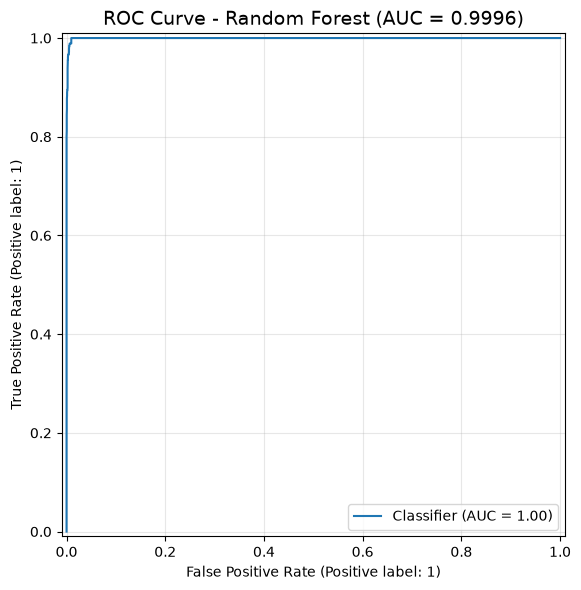

In [109]:
# ============================================================
# SAVE ROC CURVE FIGURE
# ============================================================

# Create ROC curve plot
fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_predictions(y_test, y_pred_proba, ax=ax)
plt.title(f"ROC Curve - Random Forest (AUC = {roc_auc:.4f})", fontsize=14)
plt.grid(alpha=0.3)
plt.tight_layout()

# Save the figure
save_figure("roc_curve.png")
plt.show()
print("✅ ROC curve figure saved!")

In [ ]:
# ============================================================
# CALCULATE AND SAVE FEATURE IMPORTANCE
# ============================================================

import pandas as pd

from utils.report_utils import save_feature_importance


# ------------------------------------------------------------
# Extract feature importance from the trained model
# ------------------------------------------------------------

importance_values = model.feature_importances_


# ------------------------------------------------------------
# Get feature names
# ------------------------------------------------------------

# If X_train is a DataFrame, use its column names.
# Otherwise, create generic feature names.

if hasattr(X_train, "columns"):
    feature_names = X_train.columns.tolist()

else:
    feature_names = [
        f"Feature_{i}"
        for i in range(X_train.shape[1])
    ]


# ------------------------------------------------------------
# Create feature importance DataFrame
# ------------------------------------------------------------

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance_values
})


# ------------------------------------------------------------
# Sort features by importance
# ------------------------------------------------------------

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)


# ------------------------------------------------------------
# Display top 15 features
# ------------------------------------------------------------

print("=" * 70)
print("TOP 15 MOST IMPORTANT FEATURES")
print("=" * 70)

display(
    importance_df.head(15)
)


# ------------------------------------------------------------
# Save feature importance
# ------------------------------------------------------------

feature_report = save_feature_importance(
    feature_names=importance_df["Feature"],
    importance_values=importance_df["Importance"],
    filename="random_forest_feature_importance"
)


# ------------------------------------------------------------
# Final message
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("✅ FEATURE IMPORTANCE SAVED SUCCESSFULLY")
print("=" * 70)

print(f"📊 CSV: {feature_report['csv']}")
print(f"🖼️ PNG: {feature_report['png']}")

TOP 15 MOST IMPORTANT FEATURES


,Feature,Importance
0,Feature_19,0.175369
1,Feature_21,0.167056
2,Feature_18,0.131213
3,Feature_8,0.122564
4,Feature_5,0.111884
5,Feature_20,0.111581
6,Feature_1,0.089616
7,Feature_3,0.024742
8,Feature_7,0.017053
9,Feature_2,0.014868


FEATURE IMPORTANCE SAVED
CSV: C:\Users\ayman\OneDrive\Desktop\data-analysis-project\reports\tables\random_forest_feature_importance.csv
PNG: C:\Users\ayman\OneDrive\Desktop\data-analysis-project\reports\figures\random_forest_feature_importance.png

✅ FEATURE IMPORTANCE SAVED SUCCESSFULLY
📊 CSV: C:\Users\ayman\OneDrive\Desktop\data-analysis-project\reports\tables\random_forest_feature_importance.csv
🖼️ PNG: C:\Users\ayman\OneDrive\Desktop\data-analysis-project\reports\figures\random_forest_feature_importance.png


In [ ]:
# ============================================================
# SAVE FEATURE IMPORTANCE AS CSV
# ============================================================

from utils.report_utils import save_dataframe


# ------------------------------------------------------------
# Save feature importance table
# ------------------------------------------------------------

csv_path = save_dataframe(
    dataframe=importance_df,
    filename="feature_importance"
)


# ------------------------------------------------------------
# Confirmation
# ------------------------------------------------------------

print("✅ Feature importance CSV saved successfully!")
print(f"📊 Location: {csv_path}")

Table saved: C:\Users\ayman\OneDrive\Desktop\data-analysis-project\reports\tables\feature_importance.csv
✅ Feature importance CSV saved successfully!
📊 Location: C:\Users\ayman\OneDrive\Desktop\data-analysis-project\reports\tables\feature_importance.csv


In [ ]:
# ============================================================
# CREATE MODEL SUMMARY REPORT
# ============================================================

import pandas as pd


report_text = f"""
================================================================================
MACHINE LEARNING MODEL SUMMARY REPORT
================================================================================

Generated: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}

================================================================================
MODEL INFORMATION
================================================================================

Model Type:     Random Forest Classifier
n_estimators:   100
Random State:   42
Class Weight:   balanced
Test Size:      20%

================================================================================
DATASET INFORMATION
================================================================================

Total Samples:      {len(df):,}
Training Samples:   {len(X_train):,} ({len(X_train) / len(df) * 100:.1f}%)
Testing Samples:    {len(X_test):,} ({len(X_test) / len(df) * 100:.1f}%)
Number of Features: {X_train.shape[1]}
Target Classes:     2 (No Risk, At Risk)

Class Distribution:

  - No Risk:  {target_counts[0]:,} ({target_percentages[0]:.1f}%)
  - At Risk:  {target_counts[1]:,} ({target_percentages[1]:.1f}%)

================================================================================
PERFORMANCE METRICS
================================================================================

Accuracy:   {accuracy:.4f} ({accuracy * 100:.2f}%)
Precision:  {precision:.4f}
Recall:     {recall:.4f}
F1-Score:   {f1:.4f}
ROC-AUC:    {roc_auc:.4f}

================================================================================
CLASS-WISE PERFORMANCE
================================================================================

Class 0 (No Risk):

  - Precision: {precision_0:.4f}
  - Recall:    {recall_0:.4f}
  - F1-Score:  {f1_0:.4f}

Class 1 (At Risk):

  - Precision: {precision_1:.4f}
  - Recall:    {recall_1:.4f}
  - F1-Score:  {f1_1:.4f}

================================================================================
CONFUSION MATRIX
================================================================================

                  Predicted
                 No Risk  At Risk

Actual No Risk   {cm[0, 0]:5d}    {cm[0, 1]:5d}
Actual At Risk   {cm[1, 0]:5d}    {cm[1, 1]:5d}

================================================================================
TOP 10 MOST IMPORTANT FEATURES
================================================================================

{importance_df.head(10).to_string(index=False)}

================================================================================
END OF REPORT
================================================================================
"""


print(report_text)


MACHINE LEARNING MODEL SUMMARY REPORT

Generated: 2026-08-30 15:25:03

MODEL INFORMATION

Model Type:     Random Forest Classifier
n_estimators:   100
Random State:   42
Class Weight:   balanced
Test Size:      20%

DATASET INFORMATION

Total Samples:      15,000
Training Samples:   12,000 (80.0%)
Testing Samples:    3,000 (20.0%)
Number of Features: 22
Target Classes:     2 (No Risk, At Risk)

Class Distribution:

  - No Risk:  14,100 (94.0%)
  - At Risk:  900 (6.0%)

PERFORMANCE METRICS

Accuracy:   0.9940 (99.40%)
Precision:  0.9219
Recall:     0.9833
F1-Score:   0.9516
ROC-AUC:    0.9996

CLASS-WISE PERFORMANCE

Class 0 (No Risk):

  - Precision: 0.9989
  - Recall:    0.9947
  - F1-Score:  0.9968

Class 1 (At Risk):

  - Precision: 0.9219
  - Recall:    0.9833
  - F1-Score:  0.9516

CONFUSION MATRIX

                  Predicted
                 No Risk  At Risk

Actual No Risk    2805       15
Actual At Risk       3      177

TOP 10 MOST IMPORTANT FEATURES

   Feature  Importance


In [ ]:
# ============================================================
# VERIFY ALL REPORT FILES WERE SAVED
# ============================================================

from pathlib import Path

from utils.report_utils import REPORTS_DIR


print("\n" + "=" * 80)
print("📁 VERIFYING ALL SAVED REPORT FILES")
print("=" * 80)


# ------------------------------------------------------------
# Find all files inside the reports directory
# ------------------------------------------------------------

saved_files = [
    file
    for file in REPORTS_DIR.rglob("*")
    if file.is_file()
]


# ------------------------------------------------------------
# Calculate total size
# ------------------------------------------------------------

total_size = 0


# ------------------------------------------------------------
# Display saved files
# ------------------------------------------------------------

for i, file_path in enumerate(
    sorted(saved_files),
    start=1
):

    # Get file size in KB
    file_size = file_path.stat().st_size / 1024

    total_size += file_size

    # Get path relative to reports/
    relative_path = file_path.relative_to(REPORTS_DIR)

    # Determine file type and icon
    extension = file_path.suffix.lower()

    if extension == ".json":
        icon = "📄"

    elif extension == ".txt":
        icon = "📝"

    elif extension == ".csv":
        icon = "📊"

    elif extension == ".png":
        icon = "🖼️"

    elif extension == ".npy":
        icon = "🔢"

    elif extension in [".joblib", ".pkl"]:
        icon = "🤖"

    elif extension == ".pdf":
        icon = "📕"

    else:
        icon = "📎"

    print(
        f"{i:3d}. {icon} "
        f"{str(relative_path):<60} "
        f"({file_size:.2f} KB)"
    )


# ------------------------------------------------------------
# Calculate total size in MB
# ------------------------------------------------------------

total_size_mb = total_size / 1024


# ------------------------------------------------------------
# Final summary
# ------------------------------------------------------------

print("\n" + "-" * 80)

print(f"📊 Total files: {len(saved_files)}")

print(
    f"📊 Total size:  "
    f"{total_size:.2f} KB "
    f"({total_size_mb:.2f} MB)"
)

print("=" * 80)

print(f"📁 Reports directory:")
print(f"   {REPORTS_DIR}")

print("=" * 80)


# ------------------------------------------------------------
# Check important report folders
# ------------------------------------------------------------

print("\n📂 REPORT FOLDERS")
print("-" * 80)

report_folders = [
    "figures",
    "models",
    "metrics",
    "matrices",
    "tables",
    "notebooks"
]

for folder_name in report_folders:

    folder_path = REPORTS_DIR / folder_name

    files_count = len([
        file
        for file in folder_path.rglob("*")
        if file.is_file()
    ])

    print(
        f"📁 {folder_name:<15} "
        f"→ {files_count} file(s)"
    )


print("\n" + "=" * 80)
print("✅ REPORT VERIFICATION COMPLETED")
print("=" * 80)


📁 VERIFYING ALL SAVED REPORT FILES
  1. 🖼️ figures\boxplot_Academic_Failure_Risk.png                    (44.34 KB)
  2. 🖼️ figures\boxplot_Academic_Performance_Score.png               (55.58 KB)
  3. 🖼️ figures\boxplot_Age.png                                      (33.66 KB)
  4. 🖼️ figures\boxplot_Daily_AI_Tool_Usage_Hours.png                (51.33 KB)
  5. 🖼️ figures\boxplot_Daily_Social_Media_Hours.png                 (51.73 KB)
  6. 🖼️ figures\boxplot_Mental_Health_Score.png                      (50.65 KB)
  7. 🖼️ figures\boxplot_Physical_Activity_Hours.png                  (47.52 KB)
  8. 🖼️ figures\boxplot_Physical_Health_Score.png                    (52.33 KB)
  9. 🖼️ figures\boxplot_Sleep_Hours.png                              (44.99 KB)
 10. 🖼️ figures\boxplot_Social_Isolation_Score.png                   (47.85 KB)
 11. 🖼️ figures\correlation_heatmap.png                              (459.87 KB)
 12. 🖼️ figures\countplot_Burnout_Level.png                          (88.57 KB)
 13

## 🧠 17. Interpretation of Current Results

The Random Forest model achieved very high overall accuracy.

However, the target distribution is imbalanced, with substantially fewer students in the academic-failure-risk class.

The model's recall for the positive class indicates how many at-risk students were successfully identified.

Therefore, future improvements should investigate:

- Class imbalance handling
- Feature importance
- Hyperparameter tuning
- Alternative classification models
- Threshold optimization
- Cross-validation

## 🔬 18. Future Model Improvements

The next Machine Learning improvements will include:

1. Logistic Regression baseline
2. Decision Tree classifier
3. Random Forest tuning
4. Model comparison
5. Cross-validation
6. ROC curve comparison
7. Feature importance analysis
8. Class imbalance analysis
9. Hyperparameter optimization
10. Selection of the best model

## ⚠️ 19. Important Interpretation Note

This model is an educational Machine Learning experiment.

A prediction of academic failure risk should not be interpreted as a definitive statement about a student's future performance.

The model identifies patterns present in the dataset and does not establish causation between social media usage, AI usage, health factors, and academic outcomes.

# ✅ Machine Learning Stage Completed

The Machine Learning pipeline has successfully:

✅ Loaded the cleaned dataset
✅ Prepared features and target
✅ Created engineered features
✅ Built a preprocessing pipeline
✅ Split the data into training and testing sets
✅ Trained a Random Forest classifier
✅ Evaluated model performance
✅ Generated a confusion matrix
✅ Generated an ROC curve
✅ Analyzed feature importance
✅ Saved the trained model
✅ Saved the preprocessing pipeline
✅ Saved all results and visualizations

### Final Recorded Accuracy

```text
{accuracy:.4f} ({accuracy*100:.2f}%)
```

### All Results Saved To:

```text
{get_results_directory()}
```

The next stage is model comparison and deeper Machine Learning analysis.